In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

## scikit-learn 기본 제공 와인 데이터셋 로드

In [ ]:
wine = datasets.load_wine()

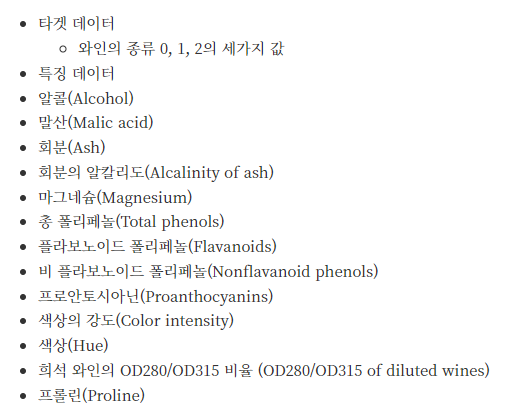

In [ ]:
print(wine['DESCR'])

## 데이터 전처리

In [ ]:
data_x = pd.DataFrame(wine['data'], columns=wine['feature_names'])

In [ ]:
data_x

In [ ]:
sns.set(rc = {'figure.figsize':(12,12)})
sns.set(font_scale=1.2)
sns.heatmap(data=data_x.corr(), square=True, annot=True, cbar=True)
plt.show()

In [ ]:
data_y = wine['target']

In [ ]:
data_y

In [ ]:
train_x, test_x, train_y, test_y=train_test_split(data_x,data_y,test_size=0.2, shuffle=True,random_state=777,stratify=data_y)
print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

In [ ]:
LB = LabelBinarizer()
test_y_bin = LB.fit_transform(test_y)

## Support Vector Classifier 학습

In [ ]:
SVM = SVC(probability=True)

SVM.fit(train_x, train_y)

## 학습 결과 검증

In [ ]:
SVM_proba = SVM.predict_proba(test_x)
SVM_pred = SVM.predict(test_x)

dftest = pd.DataFrame(np.column_stack([SVM_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(np.round(SVM_proba,3))

dftest

In [ ]:
print(classification_report(test_y,SVM_pred,target_names=wine.target_names))

In [ ]:
fpr_svm,tpr_svm,auc_svm = dict(),dict(),dict()

for i in range(3):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(test_y_bin[:, i], SVM_proba[:, i])
    auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_svm[i], tpr_svm[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(wine.target_names[i], auc_svm[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in svm',fontdict = {'fontsize' : 30})
plt.legend(loc="lower right",prop={'size': 15})
plt.show()


## Random Forest Classifier 학습

In [ ]:
RF = RandomForestClassifier()

RF.fit(train_x, train_y)

## 학습 결과 검증

In [ ]:
RF_proba = RF.predict_proba(test_x)
RF_pred = RF.predict(test_x)

dftest = pd.DataFrame(np.column_stack([RF_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(RF_proba)

dftest

In [ ]:
print(classification_report(test_y,RF_pred,target_names=wine.target_names))

In [ ]:
fpr_RF,tpr_RF,auc_RF = dict(),dict(),dict()

for i in range(3):
    fpr_RF[i], tpr_RF[i], _ = roc_curve(test_y_bin[:, i], RF_proba[:, i])
    auc_RF[i] = auc(fpr_RF[i], tpr_RF[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_RF[i], tpr_RF[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(wine.target_names[i], auc_RF[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in RF',fontdict = {'fontsize' : 30})
plt.legend(loc="lower right",prop={'size': 15})
plt.show()


## XGBoost Classifier 학습

In [ ]:
XGB = XGBClassifier()

XGB.fit(train_x, train_y)

## 학습 결과 검증

In [ ]:
XGB_proba = XGB.predict_proba(test_x)
XGB_pred = XGB.predict(test_x)

dftest = pd.DataFrame(np.column_stack([XGB_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(XGB_proba)

dftest

In [ ]:
print(classification_report(test_y,XGB_pred,target_names=wine.target_names))

In [ ]:
fpr_XGB,tpr_XGB,auc_XGB = dict(),dict(),dict()

for i in range(3):
    fpr_XGB[i], tpr_XGB[i], _ = roc_curve(test_y_bin[:, i], XGB_proba[:, i])
    auc_XGB[i] = auc(fpr_XGB[i], tpr_XGB[i])

plt.rcParams['axes.facecolor'] = 'none'
plt.figure(dpi=100)

colors = ['red', 'darkorange', 'cornflowerblue']
for i, color in zip(range(3), colors):
    plt.plot(fpr_XGB[i], tpr_XGB[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.3f})'
             ''.format(wine.target_names[i], auc_XGB[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('multi-class ROC in XGB',fontdict = {'fontsize' : 30})
plt.legend(loc="lower right",prop={'size': 15})
plt.show()
